In [15]:
import geopandas as gpd
import sys
sys.path.insert(0, '/home/lpsha/s154446/fractality/')
from dgdc.dual_conti import get_dual_dir_con
from cities.download_cities import load_city
import osmnx as ox
import matplotlib.pyplot as plt
import numpy as np
import contextily as ctx
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
import pandas as pd

In [6]:
G = load_city("Copenhagen,_Denmark")
gdf_merged, _, _, _ = get_dual_dir_con(t_buffer=10, a_threshold=20, data=G, simplify_roundabout=True, enforce_degree2=False)

In [10]:
gdf_merged.head(2)

,,geometry,index_right,osmid,edgeUID,id,mm_len,new_edge,node_start,node_end,degree,degree_log,length
346761.654463,6.172443e+06,"LINESTRING (346743.755 6172487.346, 346747.343...",66603.0,"[27256170, 243891351]","[(298795449, 2512504212, 0), (298795432, 29879...",70351,2.831856,NaN,68856,68857,6,0.778151,114.844712
346677.174373,6.172479e+06,"MULTILINESTRING ((346165.583 6172342.009, 3461...",303079.0,495928205,"[(118725, 12541976804, 0), (1288924235, 635764...",229947,48.749274,NaN,181366,181375,36,1.556303,1644.983883


/tmp/ipykernel_3179569/1473688662.py:12: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  subset.plot(ax=ax, color=cmap(b / (n_bins - 1)), linewidth=0.5)


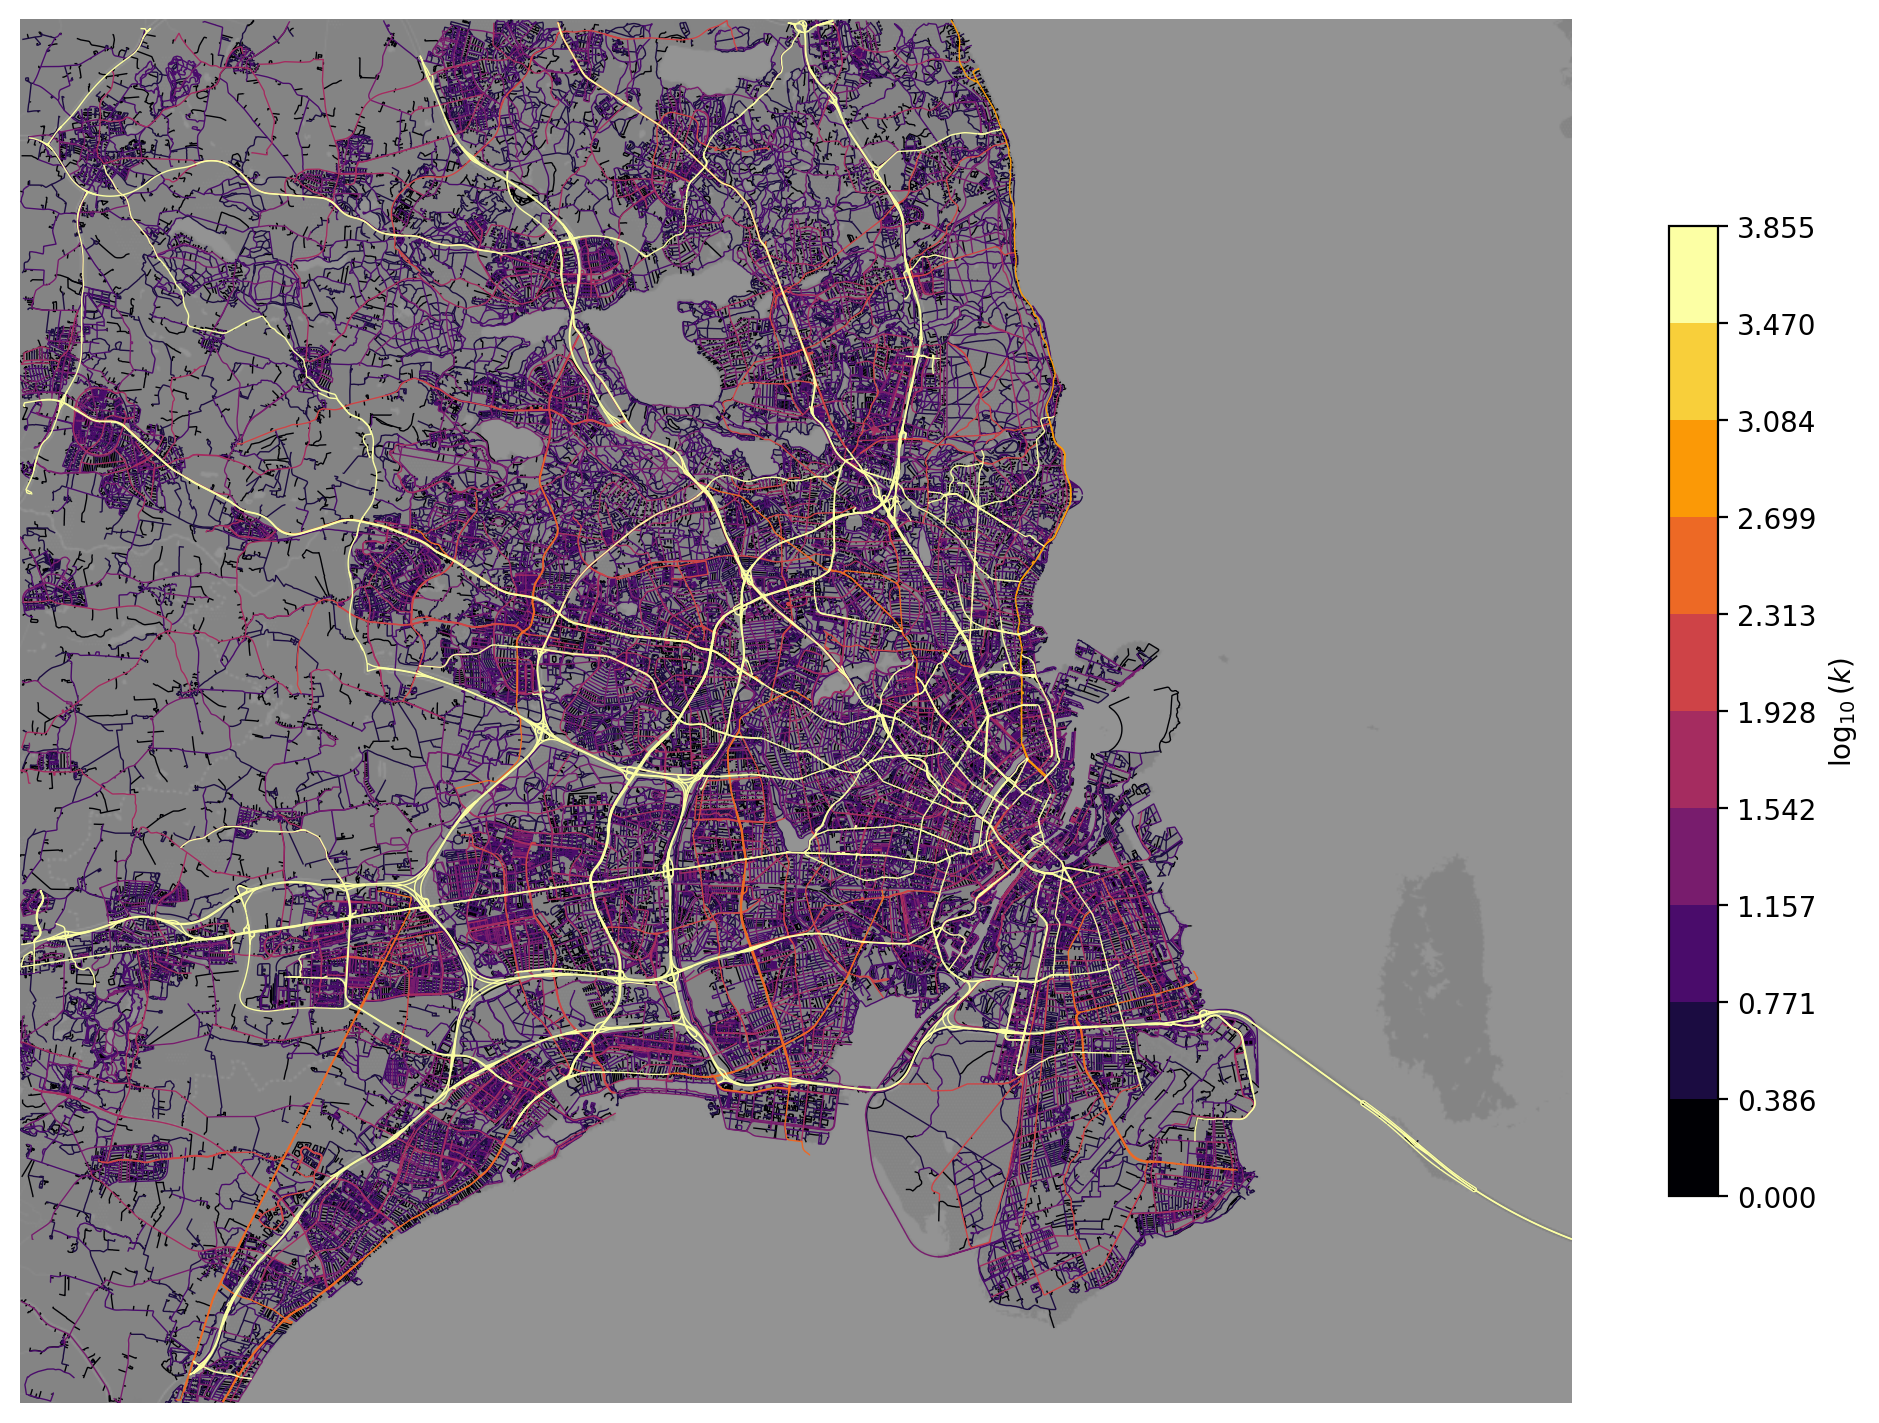

In [14]:
fig, ax = plt.subplots(figsize=(10, 10), dpi=200)

n_bins = 10
gdf_sorted = gdf_merged.to_crs("EPSG:3857").sort_values('degree_log', ascending=True)
gdf_sorted['degree_bin'] = pd.cut(gdf_sorted['degree_log'], bins=n_bins, labels=False)

cmap = plt.cm.inferno
norm = mcolors.BoundaryNorm(boundaries=np.linspace(gdf_sorted['degree_log'].min(), gdf_sorted['degree_log'].max(), n_bins + 1),ncolors=cmap.N)

for b in range(n_bins):
    subset = gdf_sorted[gdf_sorted['degree_bin'] == b]
    subset.plot(ax=ax, color=cmap(b / (n_bins - 1)), linewidth=0.5)

# Binned colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm._A = []
cbar = fig.colorbar(sm, ax=ax, shrink=0.5, spacing='proportional', ticks=np.linspace(gdf_sorted['degree_log'].min(), gdf_sorted['degree_log'].max(), n_bins + 1))

cbar.set_label(r'$\log_{10}(k)$')

# Limit axes to data extent
minx, miny, maxx, maxy = gdf_sorted.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

ctx.add_basemap(ax, source=ctx.providers.CartoDB.DarkMatterNoLabels, zoom='auto', attribution=False, alpha=0.5)
# ax.set_title("Greater Copenhagen Road Network", loc='left', pad=12)
ax.axis('off')
plt.tight_layout()
plt.show()

In [16]:
colors=['blue','red']

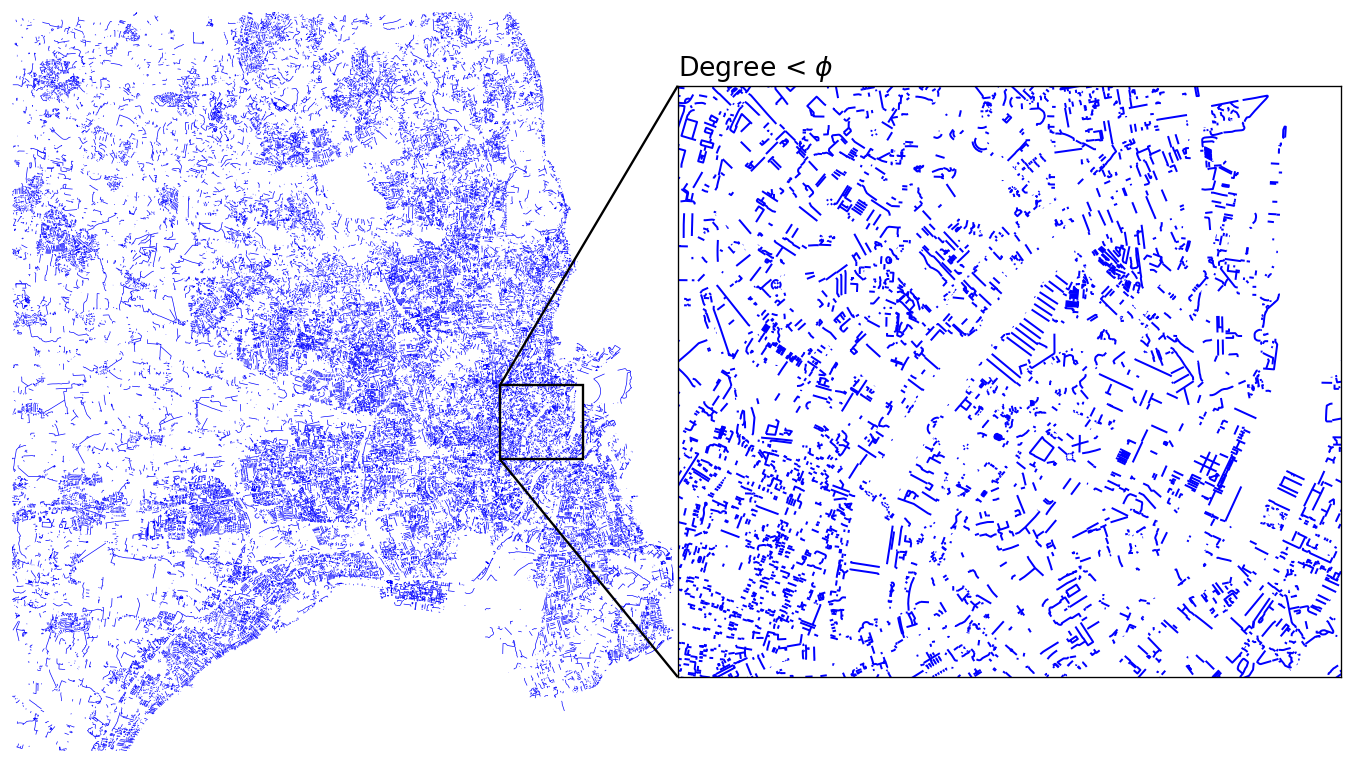

In [17]:
ps = 4

# Compute extent in Web Mercator
extent = gdf_merged.to_crs(3857).total_bounds
xmin, ymin, xmax, ymax = extent

# --- Create single subplot ---
fig, ax = plt.subplots(figsize=(15, 8), dpi=120)

# --- Plot only degree < ps ---
gdf_merged[gdf_merged.degree < ps].to_crs(3857).plot(color=colors[0], ax=ax, linewidth=0.4)

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
# ax.set_title(f"Degree > $\phi$")
ax.axis('off')

# Thicker spines (Nature-like)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(2)

# =======================================================================
#                      ★ ZOOM INSET ★
# =======================================================================

# Central 10% zoom region
x_center = (xmin + xmax) / 1.985
y_center = (ymin + ymax) / 2.001
x_range = (xmax - xmin) * 0.10
y_range = (ymax - ymin) * 0.10

x1 = x_center - x_range/2
x2 = x_center + x_range/2
y1 = y_center - y_range/2
y2 = y_center + y_range/2

axins = inset_axes(ax, width="80%", height="80%", loc="right", borderpad=-30)
gdf_merged[gdf_merged.degree < ps].to_crs(3857).plot(color=colors[0], ax=axins, linewidth=1.2)
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)
# axins.axis('off')
axins.set_xticks([])
axins.set_yticks([])
axins.set_title(f"Degree < $\phi$",loc='left',fontsize=16)
mark_inset(ax, axins, loc1=2, loc2=3, fc="none", ec="black", lw=1.4,zorder=3)
plt.show()

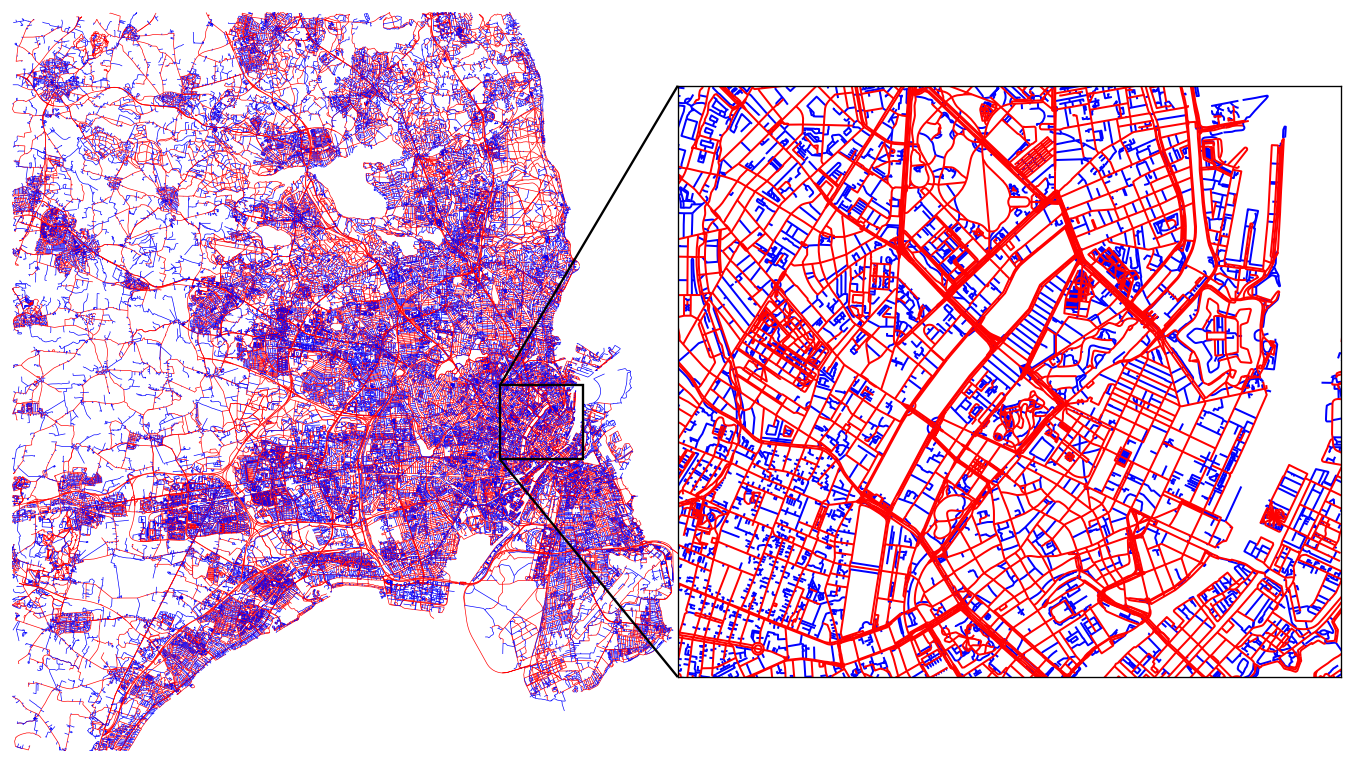

In [20]:
ps = 4

# Compute extent in Web Mercator
extent = gdf_merged.to_crs(3857).total_bounds
xmin, ymin, xmax, ymax = extent

# --- Create single subplot ---
fig, ax = plt.subplots(figsize=(15, 8), dpi=120)


gdf_merged[gdf_merged.degree > ps].to_crs(3857).plot(color=colors[1], ax=ax, linewidth=0.4)
gdf_merged[gdf_merged.degree <= ps].to_crs(3857).plot(color=colors[0], ax=ax, linewidth=0.4)

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
# ax.set_title(f"Degree > $\phi$")
ax.axis('off')

# Thicker spines (Nature-like)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(2)

# =======================================================================
#                      ★ ZOOM INSET ★
# =======================================================================

# Central 10% zoom region
x_center = (xmin + xmax) / 1.985
y_center = (ymin + ymax) / 2.001
x_range = (xmax - xmin) * 0.10
y_range = (ymax - ymin) * 0.10

x1 = x_center - x_range/2
x2 = x_center + x_range/2
y1 = y_center - y_range/2
y2 = y_center + y_range/2

axins = inset_axes(ax, width="80%", height="80%", loc="right", borderpad=-30)

gdf_merged[gdf_merged.degree <= ps].to_crs(3857).plot(color=colors[0], ax=axins, linewidth=1.2)
gdf_merged[gdf_merged.degree > ps].to_crs(3857).plot(color=colors[1], ax=axins, linewidth=1.2)

axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)
# axins.axis('off')
axins.set_xticks([])
axins.set_yticks([])
# axins.set_title(f"Degree < $\phi$",loc='left',fontsize=16)
mark_inset(ax, axins, loc1=2, loc2=3, fc="none", ec="black", lw=1.4,zorder=3)
plt.show()